# <center> **Factoración no negativa de matrices (NNMF)** </center>
## <font size=4> **Aprendizaje Estadístico 2026** </font> <font color=gray size=4> -- Alan Reyes-Figueroa </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, NMF
from sklearn.metrics.pairwise import cosine_similarity

# Data

In [2]:
ratings = pd.read_csv('ratings.csv', header=0, sep=',')
ratings.shape

(100836, 4)

In [3]:
movies = pd.read_csv('movies.csv', header=0, sep=',')
movies.shape

(9742, 3)

In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
table = pd.pivot_table(ratings, index='userId', columns='movieId', values='rating', fill_value=0)
table = table.astype(int)

In [7]:
table.shape

(610, 9724)

In [8]:
table.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4,0,4,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
X = table.values
X.shape

(610, 9724)

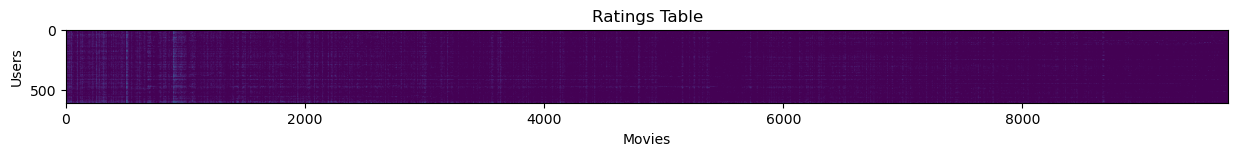

In [10]:
plt.figure(figsize=(15,6))
plt.imshow(X, vmin=0, vmax=5)
plt.title('Ratings Table')
plt.ylabel('Users')
plt.xlabel('Movies')
plt.show()

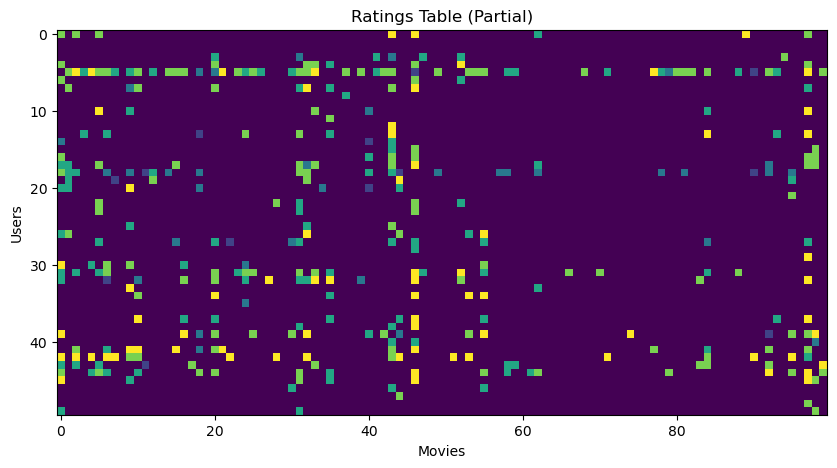

In [11]:
plt.figure(figsize=(15,5))
plt.imshow(X[:50, :100], vmin=0, vmax=5)
plt.title('Ratings Table (Partial)')
plt.ylabel('Users')
plt.xlabel('Movies')
plt.show()

## Estadísticas del conjunto de datos (Exploración)

In [12]:
n_ratings = len(ratings)
n_movies = len(ratings['movieId'].unique())
n_users = len(ratings['userId'].unique())
 
print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 100836
Number of unique movieId's: 9724
Number of unique users: 610
Average ratings per user: 165.3
Average ratings per movie: 10.37


In [13]:
user_freq = ratings[['userId', 'movieId']].groupby('userId').count().reset_index()
user_freq.columns = ['userId', 'n_ratings']

In [14]:
user_freq.head()

,userId,n_ratings
0,1,232
1,2,29
2,3,39
3,4,216
4,5,44


In [15]:
# Find Lowest and Highest rated movies:
mean_rating = ratings.groupby('movieId')[['rating']].mean()

In [16]:
mean_rating.head()

,rating
movieId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


In [17]:
# Lowest rated movies
lowest_rated = mean_rating['rating'].idxmin()
movies.loc[movies['movieId'] == lowest_rated]

,movieId,title,genres
2689,3604,Gypsy (1962),Musical


In [18]:
# Highest rated movies
highest_rated = mean_rating['rating'].idxmax()
movies.loc[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [19]:
# show number of people who rated movies rated movie highest
ratings[ratings['movieId']==highest_rated]

,userId,movieId,rating,timestamp
13368,85,53,5.0,889468268
96115,603,53,5.0,963180003


In [20]:
# show number of people who rated movies rated movie lowest
ratings[ratings['movieId']==lowest_rated]

,userId,movieId,rating,timestamp
13633,89,3604,0.5,1520408880


In [21]:
## the above movies has very low dataset. We will use bayesian average
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])

In [22]:
movie_stats.head()

rating          
         count      mean
movieId                 
1          215  3.920930
2          110  3.431818
3           52  3.259615
4            7  2.357143
5           49  3.071429

In [23]:
movie_stats.columns = movie_stats.columns.droplevel()

In [24]:
movie_stats.head()

,count,mean
movieId,,
1,215,3.920930
2,110,3.431818
3,52,3.259615
4,7,2.357143
5,49,3.071429


In [25]:
movie_stats = movie_stats.sort_values(by=['count', 'mean'], ascending=False)

In [26]:
movie_stats.iloc[1049,:]

count    25.0
mean      2.2
Name: 374, dtype: float64

### Elegimos películas con más ratings

En lugar de trabajar con la tabla completa, haremos un muestreo de las películas con más ratings. Seleccionamos como corte un número de ratings 

$$ cut >= 25 $$

y dejamos sólo aquellas películas donde que cuentan con al menos eses número de valoraciones.

In [27]:
cut = 25
movies_sample = movie_stats[movie_stats['count'] >= cut]

In [28]:
lista = list(movies_sample.index)

In [29]:
ratnumber = (X > 0).sum(0)
idX = np.argsort(ratnumber)[::-1]

<Figure size 640x480 with 0 Axes>

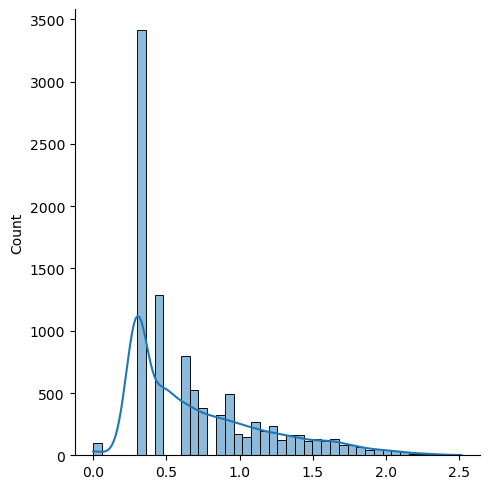

In [30]:
plt.figure()
sns.displot(np.log10(1.+ratnumber), kde=True)
plt.show()

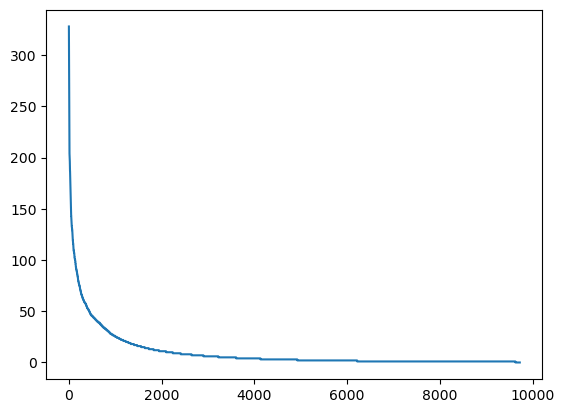

In [31]:
plt.figure()
plt.plot(ratnumber[idX])
plt.show()

In [32]:
# Select top 1050 movies (with more number of ratings)

#df_sample = pd.DataFrame(data=ratings, index=table.index, columns=table.columns[lista])

df = table[[x for x in movies_sample.index]]
Xs = df.values

#selection = [x for x in ratnumber[idX[:1000]]]
#df_sample = table.iloc[:, selection]
#X_sample =  df_sample.values

print(df.shape, Xs.shape)

(610, 1050) (610, 1050)


In [33]:
df.head()

movieId,356,318,296,593,2571,260,480,110,589,527,...,4823,1378,46530,3438,1590,3608,2598,3005,2986,374
userId,,,,,,,,,,,,,,,,,,,,,
1,4,0,3,4,5,5,4,4,0,5,...,0,0,0,0,0,0,0,0,0,0
2,0,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,5,1,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,3,5,0,0,0,0,4,3,5,...,0,0,0,0,0,0,0,0,0,0


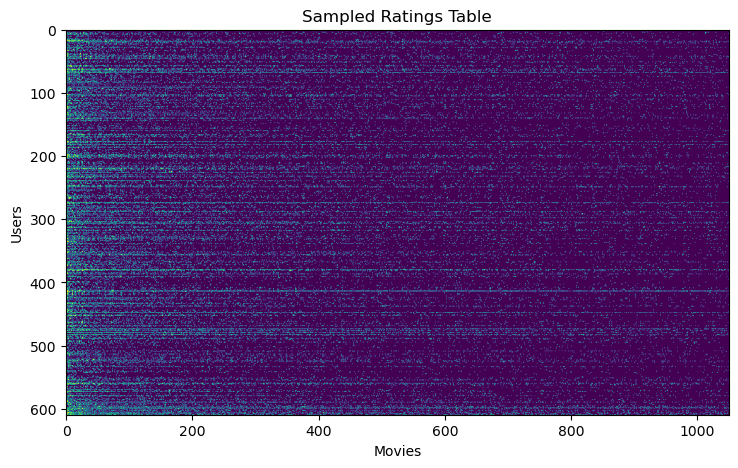

In [34]:
plt.figure(figsize=(15,5))
plt.imshow(Xs, vmin=0, vmax=5)
plt.title('Sampled Ratings Table')
plt.ylabel('Users')
plt.xlabel('Movies')
plt.show()

### Lista de Categorías

In [35]:
genres = movies['genres']

In [36]:
len(genres)

9742

In [37]:
genres[0].split('|')

['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']

In [38]:
cat = []
for i in range(0, len(genres)):
    gen = genres[i].split('|')
    for g in gen:
        if g not in cat: 
            cat.append(g)

In [39]:
print(cat)

['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy', 'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror', 'Mystery', 'Sci-Fi', 'War', 'Musical', 'Documentary', 'IMAX', 'Western', 'Film-Noir', '(no genres listed)']


# NNMF Factorization

Como hay 20 categorías distintas en la base de datos, elegimos un número de variables latentes $k = 20$. 
(Aquí estamos pensando en que las variables latentes pueden explicar las diferencias entre estos géneros o categorías de películas).

Usted puede elegir otro número diferente de variables latentes.

In [40]:
k = 20

In [41]:
model = NMF(n_components=k, init='random', max_iter=1000, random_state=2024)

W = model.fit_transform(Xs)
H = model.components_

In [42]:
print(W.shape, H.shape)

(610, 20) (20, 1050)


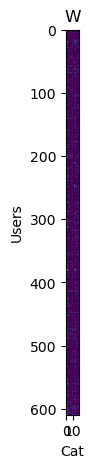

In [43]:
plt.figure(figsize=(15,5))
plt.imshow(W, vmin=0, vmax=5)
plt.title('W')
plt.ylabel('Users')
plt.xlabel('Cat')
plt.show()

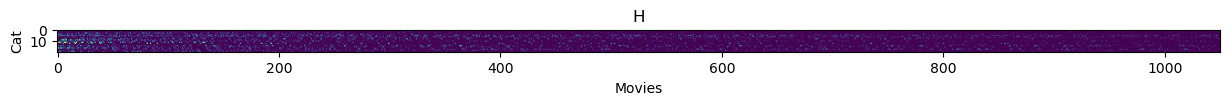

In [44]:
plt.figure(figsize=(15,5))
plt.imshow(H, vmin=0, vmax=5)
plt.title('H')
plt.ylabel('Cat')
plt.xlabel('Movies')
plt.show()

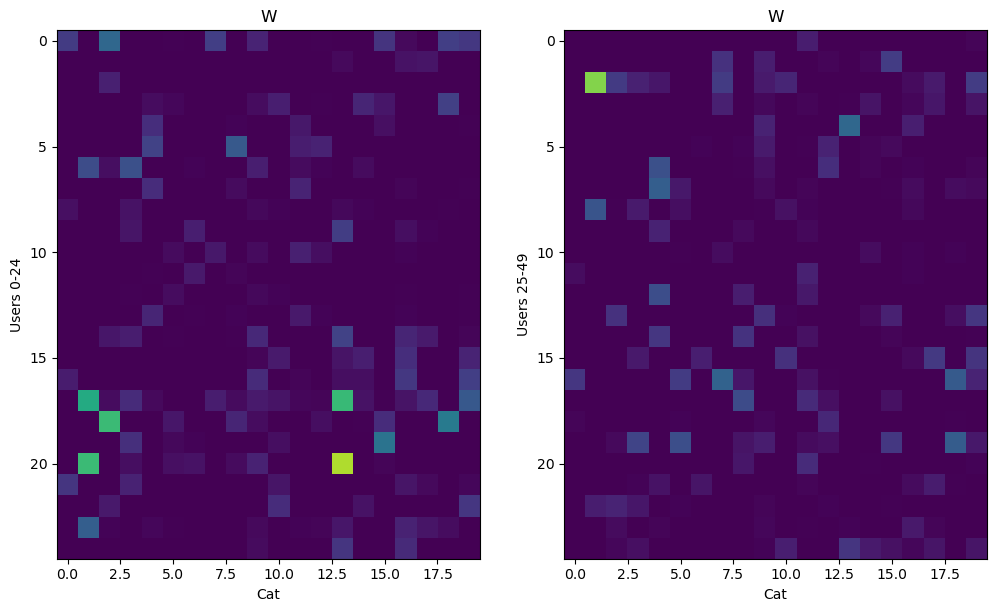

In [45]:
plt.figure(figsize=(12,12))
plt.subplot(1,2,1)
plt.imshow(W[:25,:], vmin=0, vmax=5)
plt.title('W')
plt.ylabel('Users 0-24')
plt.xlabel('Cat')
plt.subplot(1,2,2)
plt.imshow(W[25:50,:], vmin=0, vmax=5)
plt.title('W')
plt.ylabel('Users 25-49')
plt.xlabel('Cat')
plt.show()

In [46]:
# Top categorías para el userId 20
user = 20
np.argsort(W[user])[::-1]

array([13,  1,  9,  6,  5,  3,  8, 15,  7,  2,  4, 19, 18, 10, 11, 12, 14,
       16, 17,  0], dtype=int64)

In [47]:
# top 10 películas de la categoría 1
row = 1
top = np.argsort(H[row])[::-1][:10]
top

array([208, 321, 190, 308, 135, 674, 534, 438, 200, 149], dtype=int64)

In [48]:
# MovieIds de las top 10
print(df.columns[top])

Int64Index([51662, 8644, 32587, 7143, 44191, 44665, 5903, 34405, 49272, 6365], dtype='int64', name='movieId')


In [49]:
# Top 10 de la categoría
movies[movies['movieId'].isin(df.columns[top])]

,movieId,title,genres
4118,5903,Equilibrium (2002),Action|Sci-Fi|Thriller
4351,6365,"Matrix Reloaded, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX
4795,7143,"Last Samurai, The (2003)",Action|Adventure|Drama|War
5265,8644,"I, Robot (2004)",Action|Adventure|Sci-Fi|Thriller
5850,32587,Sin City (2005),Action|Crime|Film-Noir|Mystery|Thriller
5954,34405,Serenity (2005),Action|Adventure|Sci-Fi
6151,44191,V for Vendetta (2006),Action|Sci-Fi|Thriller|IMAX
6170,44665,Lucky Number Slevin (2006),Crime|Drama|Mystery
6346,49272,Casino Royale (2006),Action|Adventure|Thriller
6433,51662,300 (2007),Action|Fantasy|War|IMAX


# Sistema de Recomendación

**Ejercicio:** Construir un sistema de recomendación a partir de la factoración NNMF.

Con base en las matrices **df**, **W**, **H**, **movies**, se debe construir una función *recommender* que reciba como inputs:

* UserId   = el código del usuario (tomando como base los index de **df**).

* TopNeigh = número de usuarios vecinos a considerar.

* TopMov   = número de películas a recomendar.

La función debe devolver la lista o el DataFrame de las películas en la tabla **movies** que el usuario no haya visto, y que su sistema considere que son las más idóneas para el usuario.

In [50]:
def recommender(userId, topNeigh=10, topMov=10):
    
    return recommendations